# Myth #3: Tanh activation functions cause vanishing gradients

The code here is the same as in myth #1, except I've used different activation functions.

In [91]:
from functools import partial
import math

import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [92]:
train_ds = MNIST('data', train=True, transform=ToTensor(), download=True)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

In [93]:
num_layers = 10

In [94]:
class MLP(nn.Module):
    def __init__(self, activation=nn.ReLU):
        super().__init__()
        self.layers = nn.Sequential()
        for i in range(num_layers-1):
            self.layers.add_module(f"Dense {i+1}", nn.LazyLinear(64))
            if activation:
                self.layers.add_module(f"Activation {i+1}", activation())
        self.layers.add_module(f"Dense {num_layers})", nn.LazyLinear(10))
        
    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.layers(x)

We'll use the same He initialization function for every activation function.

In [95]:
def custom_init(gain, m):
    if isinstance(m, nn.Linear):
        std = gain * math.sqrt(2 / m.weight.shape[1])
        nn.init.normal_(m.weight, std=std)
        nn.init.zeros_(m.bias)

def apply_init(model, gain=1.0):
    torch.manual_seed(12345)
    model(torch.zeros(1, 784)) # initialize lazy layers
    init_fn = partial(custom_init, gain)
    model.apply(init_fn)

In [96]:
def compute_gradient_stds(gains, train_dl, activation=nn.ReLU):
    X, y = next(iter(train_dl))
    weight_grad_stds = [[] for _ in range(len(gains))]
    bias_grad_stds = [[] for _ in range(len(gains))]
    for i, gain in enumerate(gains):
        model = MLP(activation=activation)
        apply_init(model, gain=gain)
        logits = model(X)
        loss = F.cross_entropy(logits, y)
        loss.backward()
        for m in model.layers:
            if isinstance(m, nn.Linear):
                weight_grad_stds[i].append(
                    math.sqrt(torch.var(m.weight.grad).item()))
                bias_grad_stds[i].append(
                    math.sqrt(torch.var(m.bias.grad).item()))
    return weight_grad_stds, bias_grad_stds

In [97]:
def plot_grad_stds(ax, stds, name, title, i, j, labels, lim=None):
    x = torch.arange(num_layers) + 1
    for k, std in enumerate(stds):
        ax.plot(x, std, marker='o',
             linestyle='-', label=labels[k])
    ax.set_yscale('log')
    ax.set_title(f"{title}")
    if i == 1:
        ax.set_xlabel("Layer number")
    if j == 0:
        ax.set_ylabel(f"Standard deviation of {name} gradient")
    ax.set_xticks(list(range(1,num_layers+1)))
    ax.set_xticklabels(list(range(1,num_layers+1)),fontsize=12)
    ax.tick_params(axis='x', which='both', length=0)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    if lim:
        ax.set_ylim(lim)

### Same range of gain factors as in myth #1

In [98]:
gains = [10**i for i in range(2, -3, -1)]
print(f"Initialization gain factors: {gains}")

Initialization gain factors: [100, 10, 1, 0.1, 0.01]


In [99]:
relu_weight_stds, relu_bias_stds = compute_gradient_stds(
    gains, train_dl, activation=nn.ReLU)
linear_weight_stds, linear_bias_stds = compute_gradient_stds(
    gains, train_dl, activation=None)
sigmoid_weight_stds, sigmoid_bias_stds = compute_gradient_stds(
    gains, train_dl, activation=nn.Sigmoid)
tanh_weight_stds, tanh_bias_stds = compute_gradient_stds(
    gains, train_dl, activation=nn.Tanh)

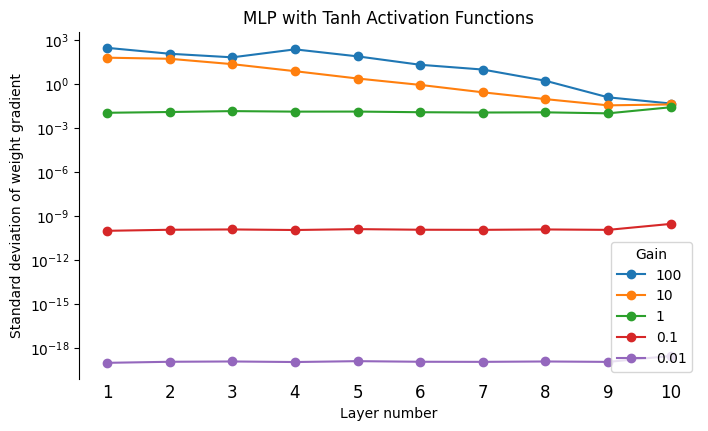

In [100]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_grad_stds(ax, tanh_weight_stds, "weight", 
               "MLP with Tanh Activation Functions", 
               1, 0, gains, lim=False)
ax.legend(title="Gain", loc='lower right') 
plt.show()

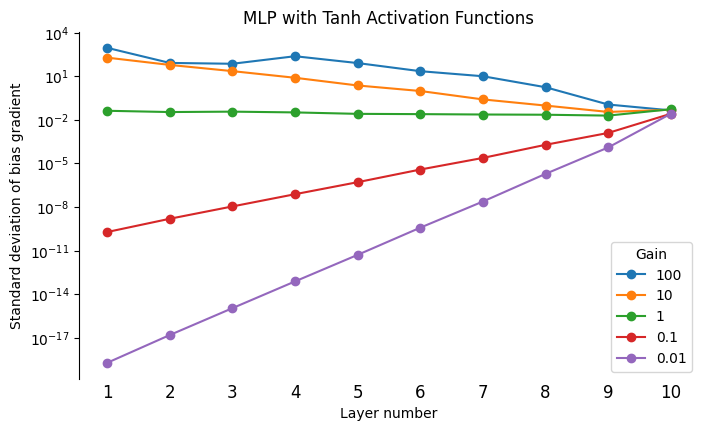

In [101]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_grad_stds(ax, tanh_bias_stds, "bias", 
               "MLP with Tanh Activation Functions", 
               1, 0, gains, lim=False)
ax.legend(title="Gain", loc='lower right')
plt.show()

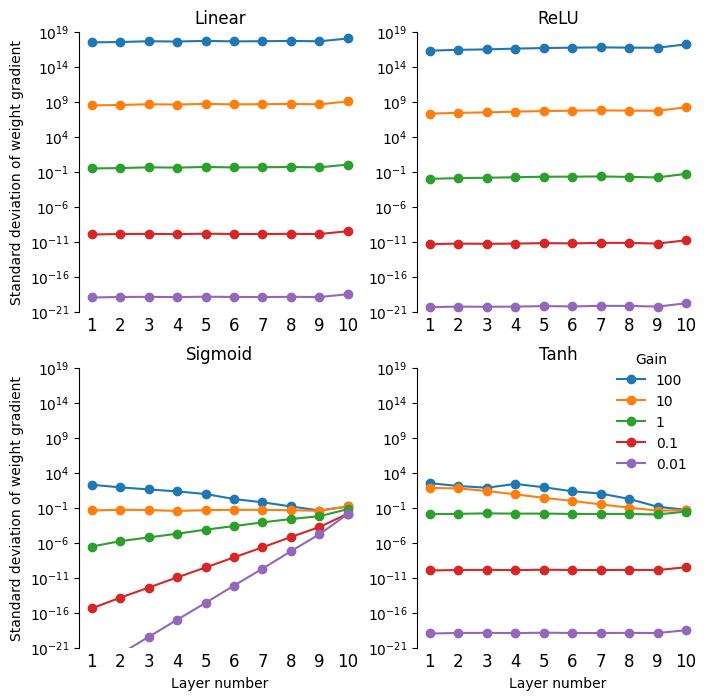

In [102]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
ylim = [10e-22,10e18]
plot_grad_stds(axs[0][0], linear_weight_stds, "weight", "Linear", 0, 0, gains, lim=ylim)
plot_grad_stds(axs[0][1], relu_weight_stds, "weight", "ReLU", 0, 1, gains, lim=ylim)
plot_grad_stds(axs[1][0], sigmoid_weight_stds, "weight", "Sigmoid", 1, 0, gains, lim=ylim)
plot_grad_stds(axs[1][1], tanh_weight_stds, "weight", "Tanh", 1, 1, gains, lim=ylim)
axs[1][1].legend(title="Gain", loc='upper right', 
                 bbox_to_anchor=(1.0, 1.1), frameon=False)
plt.savefig("myth_3_weight_gradients.png")
plt.show()

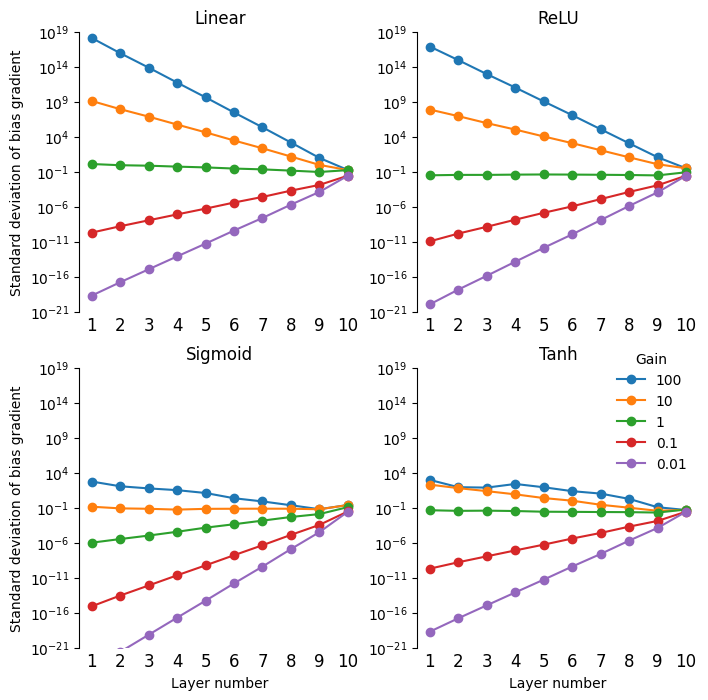

In [103]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
ylim = [10e-22,10e18]
plot_grad_stds(axs[0][0], linear_bias_stds, "bias", "Linear", 0, 0, gains, lim=ylim)
plot_grad_stds(axs[0][1], relu_bias_stds, "bias", "ReLU", 0, 1, gains, lim=ylim)
plot_grad_stds(axs[1][0], sigmoid_bias_stds, "bias", "Sigmoid", 1, 0, gains, lim=ylim)
plot_grad_stds(axs[1][1], tanh_bias_stds, "bias", "Tanh", 1, 1, gains, lim=ylim)
axs[1][1].legend(title="Gain", loc='upper right', 
                 bbox_to_anchor=(1.0, 1.1), frameon=False)
plt.savefig("myth_3_bias_gradients.png")
plt.show()

### Smaller range of gain factors

In [104]:
gains_small_range = [2**i for i in range(2, -3, -1)]
print(f"Initialization gain factors, smaller range: {gains_small_range}")

Initialization gain factors, smaller range: [4, 2, 1, 0.5, 0.25]


In [105]:
relu_weight_small_range_stds, relu_bias_small_range_stds = compute_gradient_stds(
    gains_small_range, train_dl, activation=nn.ReLU)
linear_weight_small_range_stds, linear_bias_small_range_stds = compute_gradient_stds(
    gains_small_range, train_dl, activation=None)
sigmoid_weight_small_range_stds, sigmoid_bias_small_range_stds = compute_gradient_stds(
    gains_small_range, train_dl, activation=nn.Sigmoid)
tanh_weight_small_range_stds, tanh_bias_small_range_stds = compute_gradient_stds(
    gains_small_range, train_dl, activation=nn.Tanh)

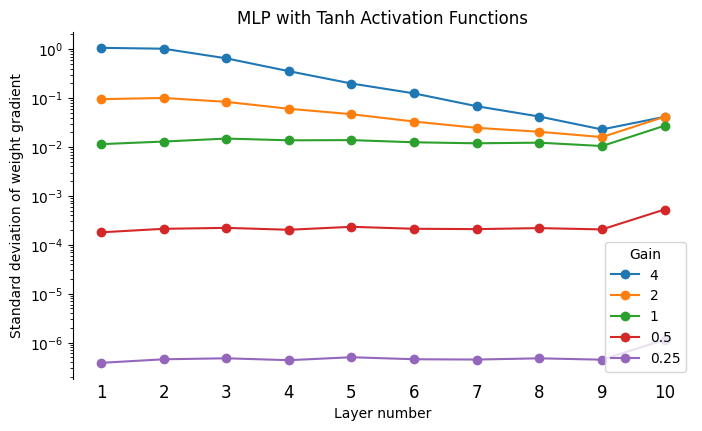

In [106]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_grad_stds(ax, tanh_weight_small_range_stds, "weight", 
               "MLP with Tanh Activation Functions", 
               1, 0, gains_small_range, lim=False)
ax.legend(title="Gain", loc='lower right') 
plt.show()

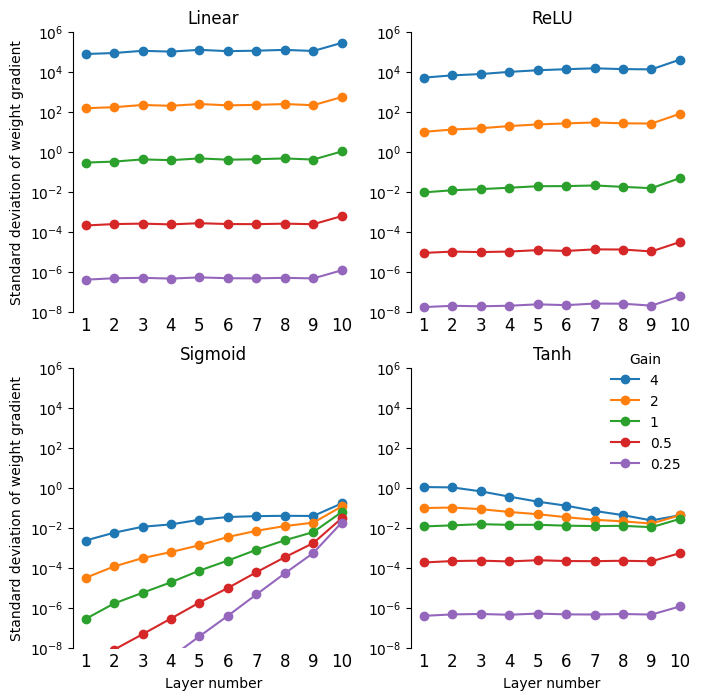

In [107]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
ylim = [10e-9, 10e5]
plot_grad_stds(axs[0][0], linear_weight_small_range_stds, "weight", "Linear", 0, 0, gains_small_range, lim=ylim)
plot_grad_stds(axs[0][1], relu_weight_small_range_stds, "weight", "ReLU", 0, 1, gains_small_range, lim=ylim)
plot_grad_stds(axs[1][0], sigmoid_weight_small_range_stds, "weight", "Sigmoid", 1, 0, gains_small_range, lim=ylim)
plot_grad_stds(axs[1][1], tanh_weight_small_range_stds, "weight", "Tanh", 1, 1, gains_small_range, lim=ylim)
axs[1][1].legend(title="Gain", loc='upper right', 
                 bbox_to_anchor=(1.0, 1.1), frameon=False)
plt.show()

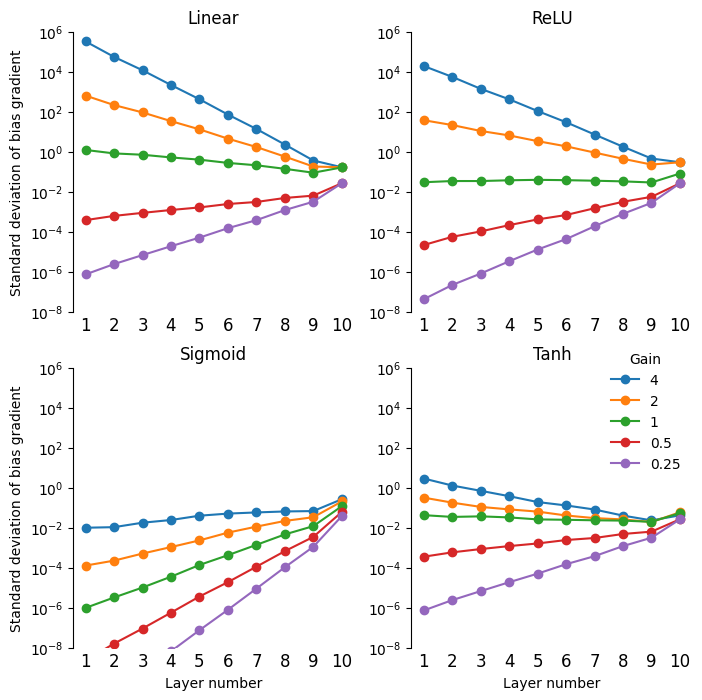

In [108]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
ylim = [10e-9, 10e5]
plot_grad_stds(axs[0][0], linear_bias_small_range_stds, "bias", "Linear", 0, 0, gains_small_range, lim=ylim)
plot_grad_stds(axs[0][1], relu_bias_small_range_stds, "bias", "ReLU", 0, 1, gains_small_range, lim=ylim)
plot_grad_stds(axs[1][0], sigmoid_bias_small_range_stds, "bias", "Sigmoid", 1, 0, gains_small_range, lim=ylim)
plot_grad_stds(axs[1][1], tanh_bias_small_range_stds, "bias", "Tanh", 1, 1, gains_small_range, lim=ylim)
axs[1][1].legend(title="Gain", loc='upper right',
                 bbox_to_anchor=(1.0, 1.1), frameon=False)
plt.show()